# Fig: Infotaxis vs MAP comparison: pmax_th=0.99

Reference: 
- `20251027_infotaxis_vs_MP_cmp_random_target_across_pm_hist_2conditions_1e-5.ipynb`
- `20251214_fig_infotaxis_MAP_cmp.ipynb`

In [1]:
from pathlib import Path

import pandas as pd

import seaborn as sns

In [2]:
from data_prep_plot.plot_utils import bar_violinplot_success
from data_prep_plot.simulation_data_prep import get_success_fname

In [3]:
# Set path
path_data = Path("/Volumes/ssd_2tb_1/infotaxis_simu_2026")

path_fig = Path("../figs_paper_2026")

Samples: left:  995    right:  515
Mean:    left: 11.117  right: 14.501
Median:  left: 10.000  right: 14.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  998    right:  545
Mean:    left: 13.630  right: 19.712
Median:  left: 13.000  right: 19.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  994    right:  534
Mean:    left: 16.262  right: 23.135
Median:  left: 15.000  right: 22.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  993    right:  501
Mean:    left: 24.377  right: 34.509
Median:  left: 22.000  right: 32.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


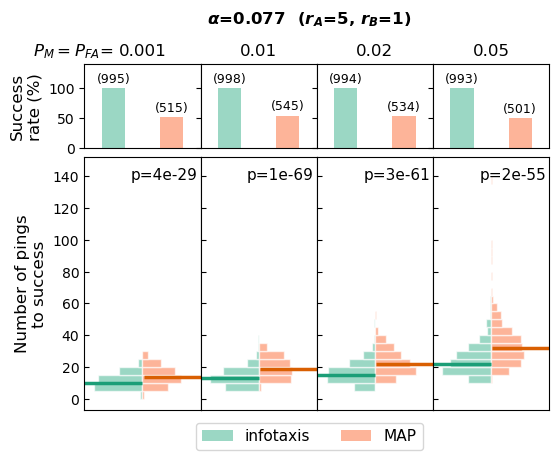

Samples: left:  996    right:  339
Mean:    left: 8.448  right: 11.383
Median:  left: 8.000  right: 11.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  997    right:  303
Mean:    left: 12.872  right: 17.587
Median:  left: 12.000  right: 17.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  989    right:  300
Mean:    left: 17.197  right: 23.053
Median:  left: 16.000  right: 22.500

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  992    right:  298
Mean:    left: 38.701  right: 43.872
Median:  left: 36.000  right: 42.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


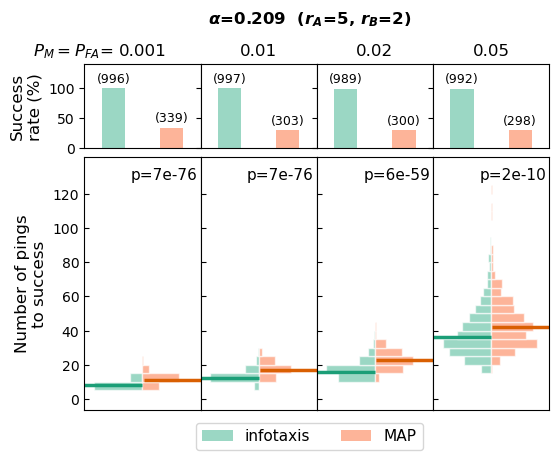

Samples: left:  998    right:  528
Mean:    left: 30.255  right: 37.587
Median:  left: 29.000  right: 34.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  997    right:  536
Mean:    left: 34.887  right: 46.039
Median:  left: 33.000  right: 42.500

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  995    right:  520
Mean:    left: 39.646  right: 55.423
Median:  left: 37.000  right: 52.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  995    right:  510
Mean:    left: 61.048  right: 80.867
Median:  left: 53.000  right: 72.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


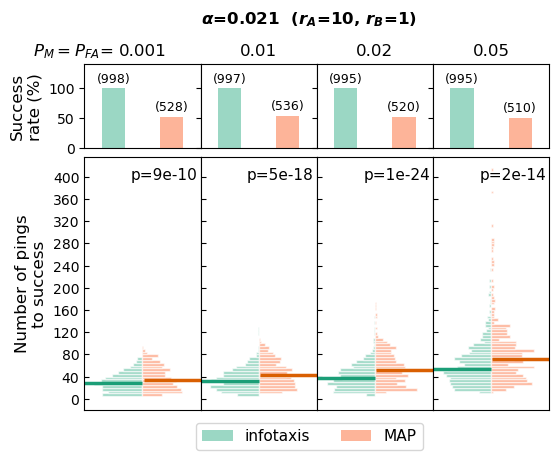

Samples: left:  999    right:  314
Mean:    left: 16.054  right: 20.838
Median:  left: 15.000  right: 20.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  992    right:  332
Mean:    left: 22.598  right: 30.663
Median:  left: 21.000  right: 30.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  991    right:  306
Mean:    left: 30.812  right: 40.912
Median:  left: 29.000  right: 39.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  994    right:  244
Mean:    left: 68.055  right: 82.734
Median:  left: 67.000  right: 76.500

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


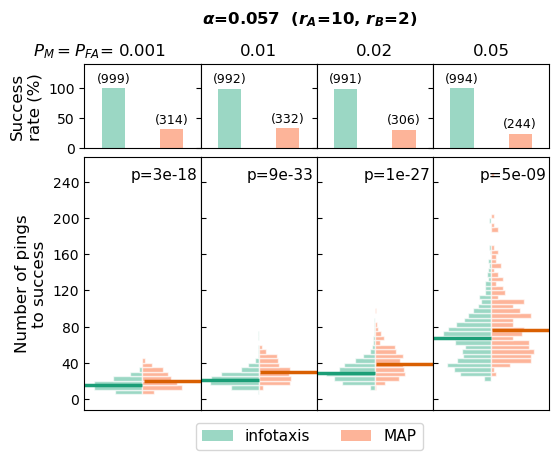

In [4]:
cr_all = [5, 10]
br_all = [1, 2]
pm_all = [0.001, 0.01, 0.02, 0.05]

for cr in cr_all:
    for br in br_all:

        path_left = path_data / "20260530_infotaxis_match_summary_compiled_pmax099_pmaxDiff1e-5"
        path_right = path_data / "20260530_MAP_match_summary_compiled_pmax099_pmaxDiff1e-5"
        pmax_th = 0.99
        pmax_diff_th=1e-5

        df_x_all = []
        df_y_all = []
        for pm in pm_all:
            # Load summary and ph details
            df_x = pd.read_csv(
                path_left / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="simple",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm
                ), index_col=0
            )
            df_y = pd.read_csv(
                path_right / get_success_fname(
                    search_type="MAP", cr=cr, br=br, simulation_type="simple",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm
                ), index_col=0
            )
            df_x_all.append(df_x)
            df_y_all.append(df_y)


        fig = bar_violinplot_success(
            cr=cr, br=br, pm_all=pm_all,
            df_x_all=df_x_all, df_y_all=df_y_all,
            x_str="infotaxis", y_str="MAP",
            color_idx_left=0, color_idx_right=1,
            comparison_type="simple",
            stats_type="less",
            colors = sns.color_palette("Set2"),
            colors_dark = sns.color_palette("Dark2"),
            print_stats=True,
        )

        fig.savefig(
            path_fig / f"fig_infotaxis_MAP_cmp_cr{cr}_br{br}_pmaxTh0.99_pmaxDiff1e-5.png",
            dpi=300, bbox_inches="tight"
        )